# YAFS Simulation Trace Analysis

This notebook analyzes the `sim_trace.csv` file generated by the YAFS simulation. It focuses on:
- **Latency Analysis**: End-to-end delay of messages.
- **Service Time**: Processing time within modules.
- **Traffic Distribution**: Message counts per application and module.
- **Topology Flow**: Communication patterns between Fog and Cloud nodes.

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load and Inspect Data
Load the CSV file and check the structure.

In [38]:
# Load the dataset
# Update to the specific results file generated by the tutorial
file_path = 'resultados/5-roundRobin-sim_trace.csv'
df = pd.read_csv(file_path)

# Display first rows
display(df.head())

# Check info
print(df.info())

,id,type,app,module,message,DES.src,DES.dst,TOPO.src,TOPO.dst,TOPO.srcLabel,TOPO.dstLabel,module.src,service,time_in,time_out,time_emit,time_reception
0,-1,COMP_M,Application-904,Application-904-Service,M_Req,3382,3381,1888,5,Application-904-Sensor,Fog-4,Application-904-Sensor,0.001160,181.207136,181.208296,0.0,181.207136
1,-1,COMP_M,Application-545,Application-545-Service,M_Req,2664,2663,1170,1,Application-545-Sensor,Fog-0,Application-545-Sensor,0.001648,182.892799,182.894447,0.0,182.892799
2,-1,COMP_M,Application-922,Application-922-Service,M_Req,3418,3417,1924,3,Application-922-Sensor,Fog-2,Application-922-Sensor,0.001136,185.674013,185.675149,0.0,185.674013
3,-1,COMP_M,Application-680,Application-680-Service,M_Req,2934,2933,1440,1,Application-680-Sensor,Fog-0,Application-680-Sensor,0.002060,186.646728,186.648788,0.0,186.646728
4,-1,COMP_M,Application-379,Application-379-Service,M_Req,2332,2331,838,5,Application-379-Sensor,Fog-4,Application-379-Sensor,0.001027,187.269121,187.270148,0.0,187.269121


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1487 entries, 0 to 1486
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              1487 non-null   int64  
 1   type            1487 non-null   object 
 2   app             1487 non-null   object 
 3   module          1487 non-null   object 
 4   message         1487 non-null   object 
 5   DES.src         1487 non-null   int64  
 6   DES.dst         1487 non-null   int64  
 7   TOPO.src        1487 non-null   int64  
 8   TOPO.dst        1487 non-null   int64  
 9   TOPO.srcLabel   1487 non-null   object 
 10  TOPO.dstLabel   1487 non-null   object 
 11  module.src      1487 non-null   object 
 12  service         1487 non-null   float64
 13  time_in         1487 non-null   float64
 14  time_out        1487 non-null   float64
 15  time_emit       1487 non-null   float64
 16  time_reception  1487 non-null   float64
dtypes: float64(5), int64(5), object(7

## 2. Data Preprocessing
Calculate key metrics:
- **Latency**: `service`
- **Service Time**: `time_out - time_in`
- **Network/Wait Time**: `Latency - Service Time`

In [39]:
# Calculate Latency
df['Latency'] = df['service']

# Calculate Service Time (Processing Duration)
df['Service_Time'] = df['time_out'] - df['time_in']

# Calculate Network + Wait Time
df['Network_Wait_Time'] = df['Latency'] - df['Service_Time']

# Create a combined label for Application and Node
df['App_Node'] = df['app'] + ' (' + df['TOPO.dstLabel'] + ')'

# Display summary stats for these new metrics
df[['Latency', 'Service_Time', 'Network_Wait_Time']].describe()

,Latency,Service_Time,Network_Wait_Time
count,1487.000000,1487.000000,1.487000e+03
mean,0.153639,0.153639,6.812916e-16
std,0.327481,0.327481,4.931658e-14
min,0.000765,0.000765,-2.835510e-13
25%,0.001191,0.001191,-2.325917e-14
50%,0.001957,0.001957,2.949030e-16
75%,0.291634,0.291634,2.318490e-14
max,4.576744,4.576744,2.796652e-13


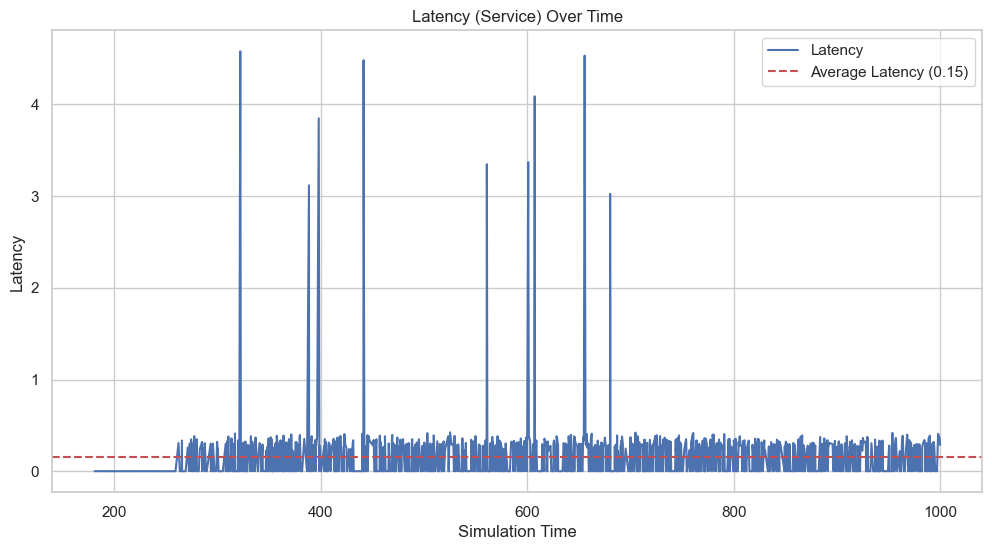

In [40]:
# Simple Line Plot: Latency (Service) over Time
plt.figure(figsize=(12, 6))
sns.lineplot(x='time_reception', y='service', data=df, label='Latency')

# Calculate and plot average
mean_latency = df['service'].mean()
plt.axhline(y=mean_latency, color='r', linestyle='--', label=f'Average Latency ({mean_latency:.2f})')

plt.title('Latency (Service) Over Time')
plt.xlabel('Simulation Time')
plt.ylabel('Latency')
plt.legend()
plt.show()

## 3. Descriptive Statistics
Analyze the frequency of applications, modules, and message types.

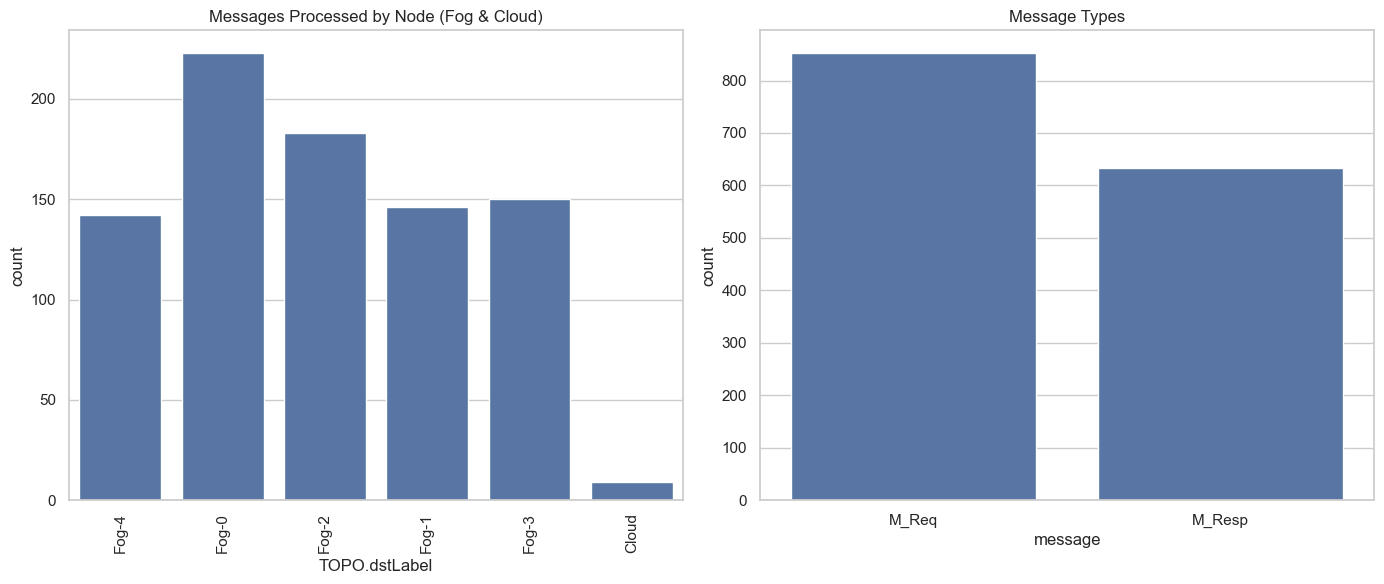

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Messages Processed by Node (Physical Node only)
# Filter for M_Req messages to show only Fog/Cloud nodes (Service providers)
# M_Resp messages go back to Sensors (Users), so we exclude them here.
df_fog_cloud = df[df['message'] == 'M_Req']
sns.countplot(x='TOPO.dstLabel', data=df_fog_cloud, ax=axes[0])
axes[0].set_title('Messages Processed by Node (Fog & Cloud)')
axes[0].tick_params(axis='x', rotation=90)

# 2. Message Types
# We use the 'message' column to distinguish M_Req, M_Resp, M_Act
sns.countplot(x='message', data=df, ax=axes[1])
axes[1].set_title('Message Types')

plt.tight_layout()
plt.show()

## 4. Latency Analysis
Visualize the distribution of latency and compare it across applications.

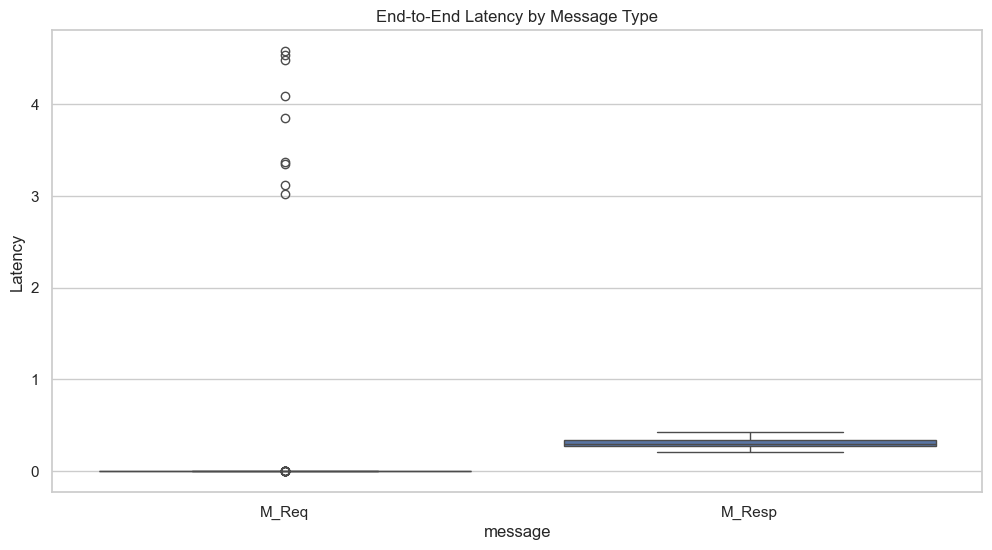

In [42]:
# Latency Distribution by Message Type
plt.figure(figsize=(12, 6))
sns.boxplot(x='message', y='Latency', data=df)
plt.title('End-to-End Latency by Message Type')
plt.show()

## 5. Service Time Analysis
Compare processing times across different nodes (Fog vs Cloud).

## 6. Traffic Load Over Time
Check if the traffic is constant or bursty.

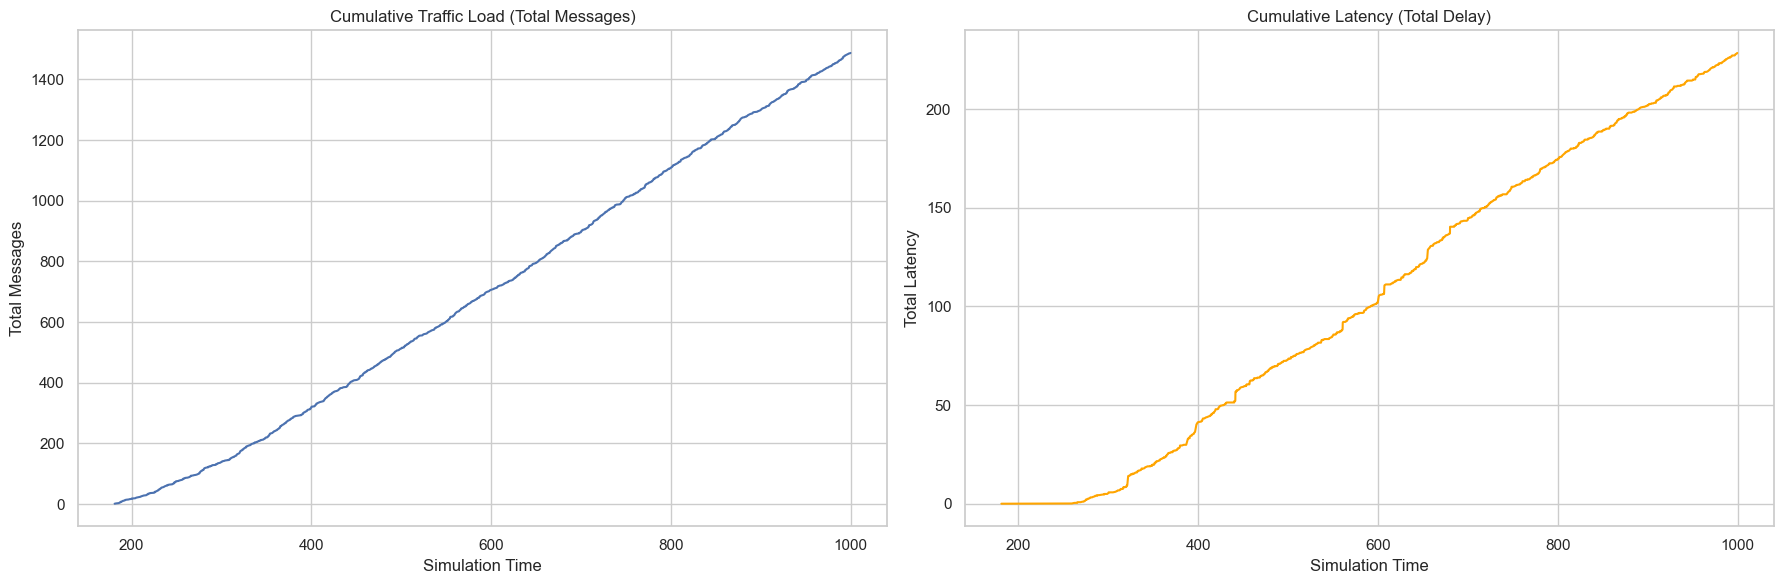

In [ ]:
# Sort by time_reception to ensure correct cumulative sum
df_sorted = df.sort_values('time_reception')

# Calculate cumulative sum of messages
df_sorted['cumulative_messages'] = np.arange(1, len(df_sorted) + 1)

# Calculate cumulative sum of latency
df_sorted['cumulative_latency'] = df_sorted['service'].cumsum()

# Plot 1: Cumulative Messages
plt.figure(figsize=(12, 6))
sns.lineplot(x='time_reception', y='cumulative_messages', data=df_sorted)
plt.title('Cumulative Traffic Load (Total Messages) Over Time')
plt.xlabel('Simulation Time')
plt.ylabel('Total Messages')
plt.show()

# Plot 2: Cumulative Latency
plt.figure(figsize=(12, 6))
sns.lineplot(x='time_reception', y='cumulative_latency', data=df_sorted, color='orange')
plt.title('Cumulative Latency (Total Delay) Over Time')
plt.xlabel('Simulation Time')
plt.ylabel('Total Latency')
plt.show()

## 7. Network Topology Flow
Visualize the communication frequency between different nodes.

In [44]:
# Create a pivot table (crosstab) showing communication frequency
communication_table = pd.crosstab(df['TOPO.srcLabel'], df['TOPO.dstLabel'])

print("Communication Table (Source Node vs Destination Node):")
display(communication_table)

Communication Table (Source Node vs Destination Node):


TOPO.dstLabel,Application-10-Sensor,Application-100-Sensor,Application-1003-Sensor,Application-1006-Sensor,Application-1007-Sensor,Application-1019-Sensor,Application-102-Sensor,Application-1033-Sensor,Application-105-Sensor,Application-1076-Sensor,...,Application-970-Sensor,Application-98-Sensor,Application-994-Sensor,Application-995-Sensor,Cloud,Fog-0,Fog-1,Fog-2,Fog-3,Fog-4
TOPO.srcLabel,,,,,,,,,,,,,,,,,,,,,
Application-10-Sensor,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
Application-100-Sensor,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,2,0,0,0,0
Application-1001-Sensor,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
Application-1003-Sensor,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
Application-1006-Sensor,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fog-0,1,2,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
Fog-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Fog-2,0,0,0,0,0,0,1,0,0,0,...,3,0,0,0,0,0,0,0,0,0


## 8. Conclusion
This notebook provides a comprehensive overview of the simulation results.
- **Latency**: Check the boxplots to see if any application suffers from high latency.
- **Service Time**: Compare Fog vs Cloud nodes to see if Fog nodes are processing faster or if they are overloaded.
- **Traffic**: Ensure the load is distributed as expected and not saturating specific nodes (check the Heatmap).

## 6. Unprocessed Messages Analysis (Congestion/Loss)
Analyze messages that did not complete before the simulation ended. This indicates severe congestion or bottlenecks.

Total Unprocessed Messages: 13693


,QueueType,App,Message,Src,Dst,Timestamp,Path,CurrentNode,Until
0,Network_Wait,Application-699,M_Req,Application-699-Sensor,Application-699-Service,0,"[1478, 1477, 39, 3]",3,1043.533761
1,Network_Wait,Application-700,M_Req,Application-700-Sensor,Application-700-Service,0,"[1480, 1479, 39, 3]",3,1157.084737
2,Network_Wait,Application-1177,M_Req,Application-1177-Sensor,Application-1177-Service,0,"[2434, 2433, 62, 1, 0]",1,1029.343950
3,Network_Wait,Application-84,M_Req,Application-84-Sensor,Application-84-Service,0,"[248, 247, 9, 2]",2,1043.606577
4,Network_Wait,Application-980,M_Req,Application-980-Sensor,Application-980-Service,0,"[2040, 2039, 52, 4, 0, 5]",4,1056.903309


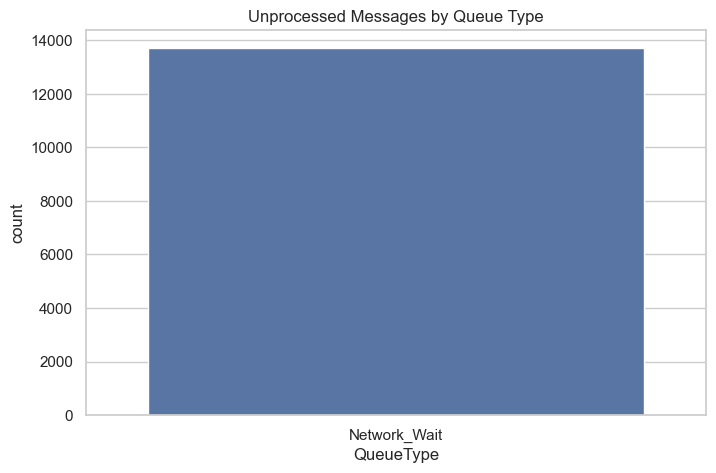

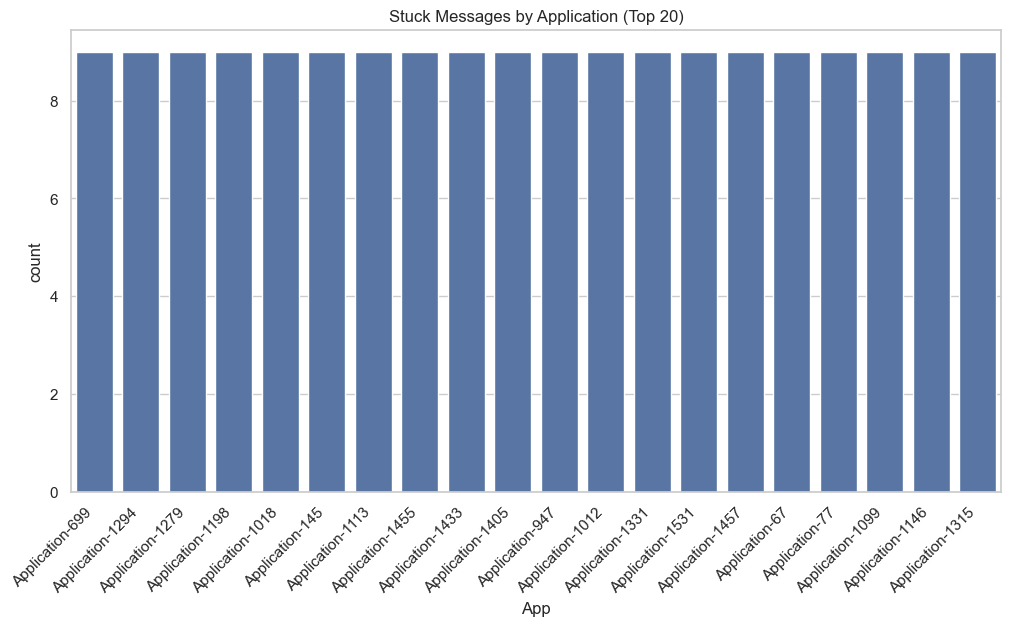

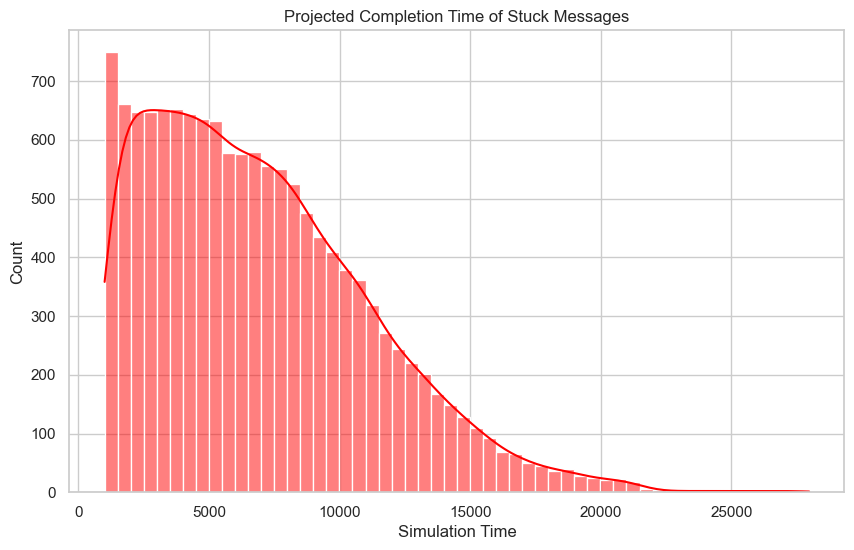

In [45]:
import os

unprocessed_path = 'resultados/unprocessed_messages.csv'

if os.path.exists(unprocessed_path):
    df_unprocessed = pd.read_csv(unprocessed_path)
    
    print(f"Total Unprocessed Messages: {len(df_unprocessed)}")
    
    if len(df_unprocessed) > 0:
        display(df_unprocessed.head())
        
        # 1. Count by Queue Type
        plt.figure(figsize=(8, 5))
        sns.countplot(x='QueueType', data=df_unprocessed)
        plt.title('Unprocessed Messages by Queue Type')
        plt.show()
        
        # 2. Count by Application (Top 20)
        top_stuck_apps = df_unprocessed['App'].value_counts().nlargest(20).index
        df_stuck_top20 = df_unprocessed[df_unprocessed['App'].isin(top_stuck_apps)]
        
        plt.figure(figsize=(12, 6))
        sns.countplot(x='App', data=df_stuck_top20, order=top_stuck_apps)
        plt.title('Stuck Messages by Application (Top 20)')
        plt.xticks(rotation=45, ha='right')
        plt.show()
        
        # 3. Distribution of "Until" time (Projected Completion Time)
        # Filter out N/A values if any
        df_unprocessed['Until'] = pd.to_numeric(df_unprocessed['Until'], errors='coerce')
        
        plt.figure(figsize=(10, 6))
        sns.histplot(df_unprocessed['Until'].dropna(), kde=True, color='red')
        plt.title('Projected Completion Time of Stuck Messages')
        plt.xlabel('Simulation Time')
        plt.show()
        
    else:
        print("No unprocessed messages found. Great!")
else:
    print("unprocessed_messages.csv not found.")